In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Helper function to show images inline
def show(img, title=None, size=8):
    plt.figure(figsize=(size, size))
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


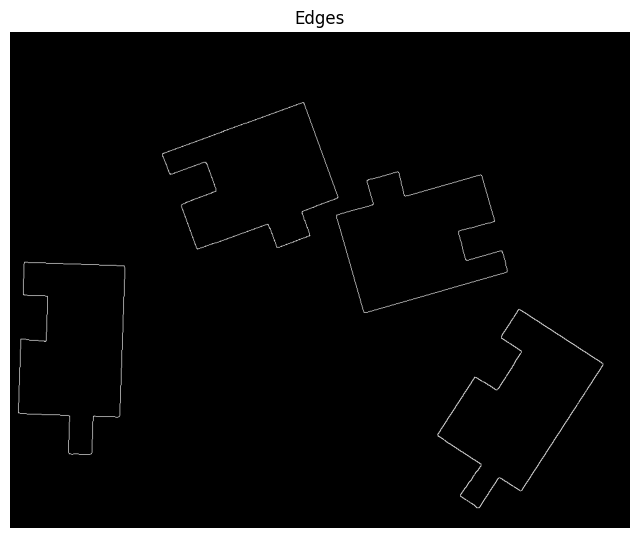

In [3]:
# Load your image here
# Example: img = cv2.imread('puzzle.jpg')
img = cv2.imread('../assets/puzzle_images/simulator_01.png')

# Resize for easier viewing if large
scale = 0.5
img = cv2.resize(img, None, fx=scale, fy=scale)

# Convert to grayscale and blur to reduce noise
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Edge detection
edges = cv2.Canny(blur, 50, 150)

show(edges, "Edges")


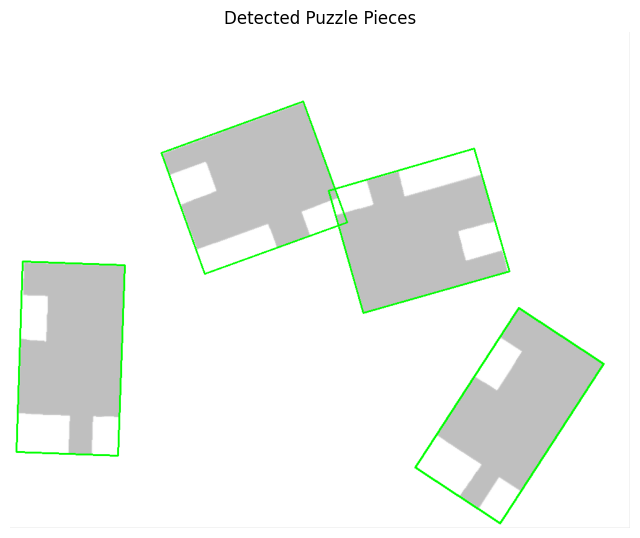

Detected 4 puzzle pieces


In [ ]:
# Find contours of pieces
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

pieces = []
img_contours = img.copy()

for c in contours:
    area = cv2.contourArea(c)
    if area > 200:
        rect = cv2.minAreaRect(c)
        box = cv2.boxPoints(rect)
        box = box.astype(int)
        cv2.drawContours(img_contours, [box], 0, (0,255,0), 2)
        pieces.append((c, rect))

show(img_contours, "Detected Puzzle Pieces")
print(f"Detected {len(pieces)} puzzle pieces")


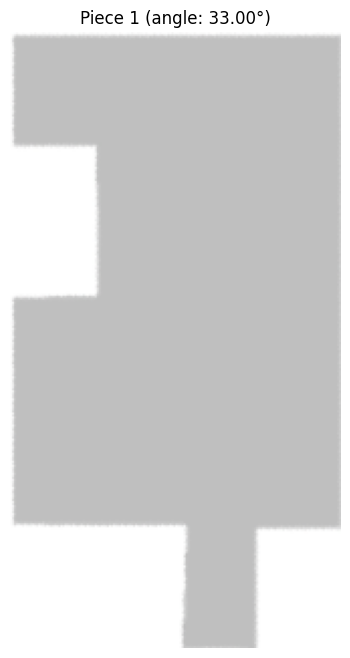

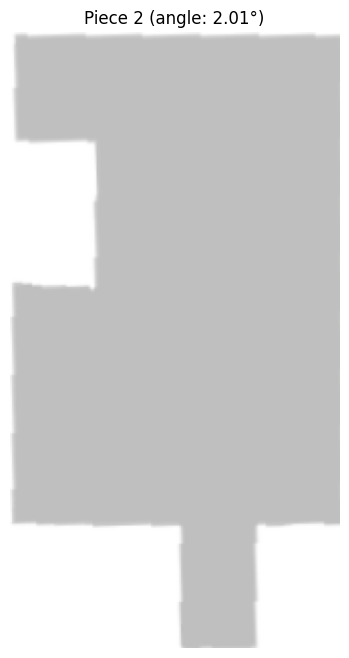

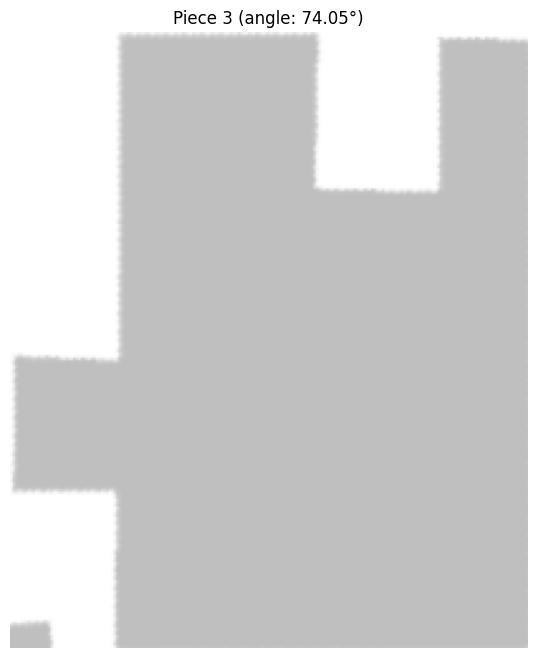

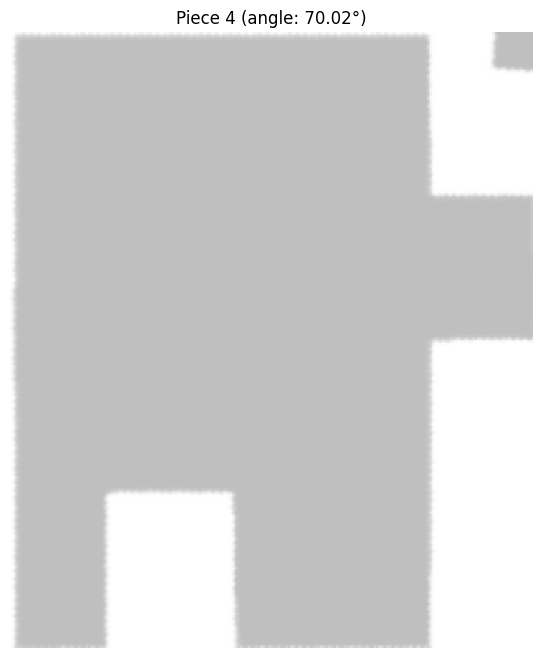

In [8]:
extracted_pieces = []

for i, (cnt, rect) in enumerate(pieces):
    center, size, angle = rect
    width, height = map(int, size)

    # Rotation matrix
    M = cv2.getRotationMatrix2D(center, angle, 1)
    rotated = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))

    # Crop the piece using bounding box
    x, y = int(center[0] - width/2), int(center[1] - height/2)
    piece = rotated[y:y+height, x:x+width]
    extracted_pieces.append((piece, angle))

    show(piece, f"Piece {i+1} (angle: {angle:.2f}°)")


Extracted edges for 4 pieces


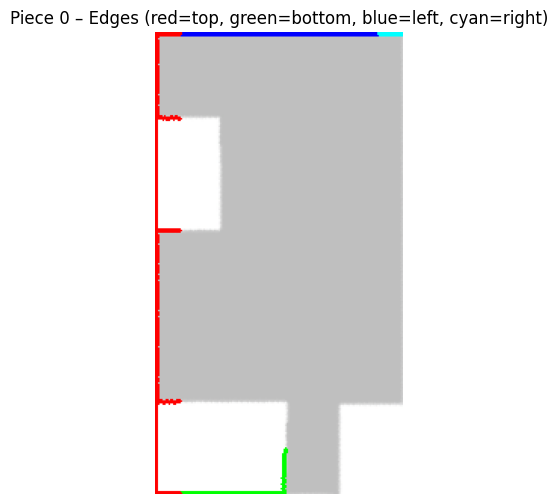

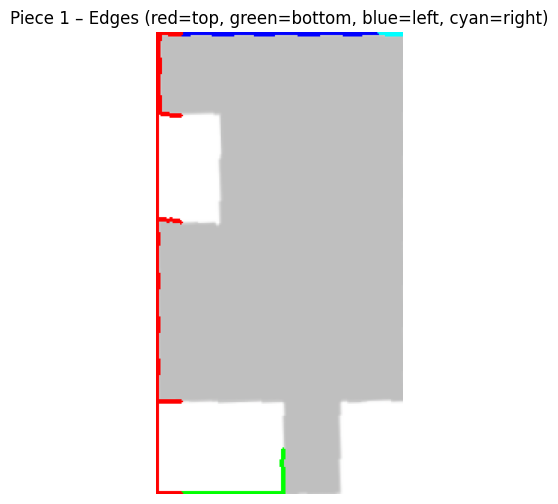

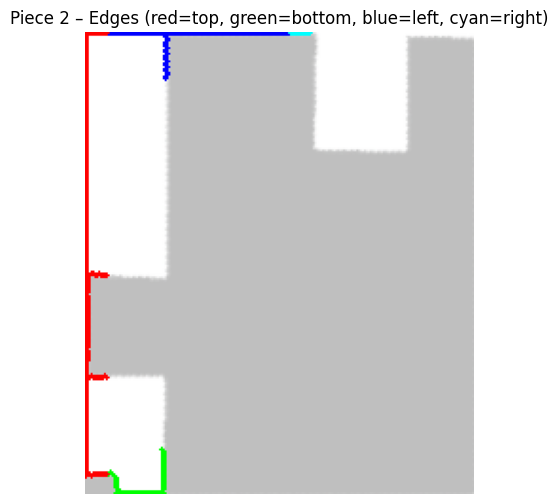

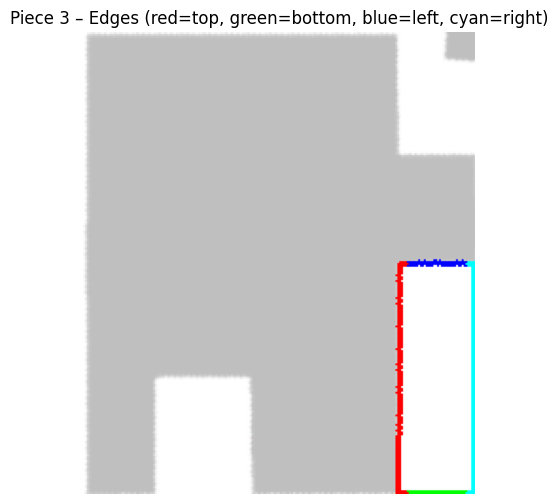

In [ ]:
def get_edges(piece_img, piece_id):
    gray = cv2.cvtColor(piece_img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    if not contours:
        return None

    contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(contour)

    edges = {
        "top":    contour[(contour[:,0,1] < y + 0.1*h).flatten()],
        "bottom": contour[(contour[:,0,1] > y + 0.9*h).flatten()],
        "left":   contour[(contour[:,0,0] < x + 0.1*w).flatten()],
        "right":  contour[(contour[:,0,0] > x + 0.9*w).flatten()],
    }

    return edges

pieces_edges = []
for i, (piece, _) in enumerate(extracted_pieces):
    edges = get_edges(piece, i)
    if edges:
        pieces_edges.append((i, edges))

print(f"Extracted edges for {len(pieces_edges)} pieces")

# Visualization of the extracted edges for each piece
colors = {
    "top": (255, 0, 0),      # red
    "bottom": (0, 255, 0),   # green
    "left": (0, 0, 255),     # blue
    "right": (255, 255, 0),  # cyan
}

for i, (piece_id, edges) in enumerate(pieces_edges):
    piece_img = extracted_pieces[piece_id][0].copy()

    # Draw all detected edge segments
    for side, pts in edges.items():
        if len(pts) == 0:
            continue
        for p in pts:
            cv2.circle(piece_img, tuple(p[0]), 1, colors[side], -1)

    show(piece_img, f"Piece {piece_id} – Edges (red=top, green=bottom, blue=left, cyan=right)", size=6)


In [11]:
def compare_edges(edge_a, edge_b):
    if len(edge_a) < 5 or len(edge_b) < 5:
        return np.inf  # too few points to compare
    return cv2.matchShapes(edge_a, edge_b, cv2.CONTOURS_MATCH_I3, 0.0)

matches = []

for i, (id_a, edges_a) in enumerate(pieces_edges):
    for j, (id_b, edges_b) in enumerate(pieces_edges):
        if i >= j:
            continue  # avoid duplicates
        for side_a, contour_a in edges_a.items():
            for side_b, contour_b in edges_b.items():
                score = compare_edges(contour_a, contour_b)
                if score < 0.3:  # tweak threshold as needed
                    matches.append((id_a, side_a, id_b, side_b, score))

matches = sorted(matches, key=lambda x: x[-1])
print(f"Found {len(matches)} potential matches")


Found 8 potential matches


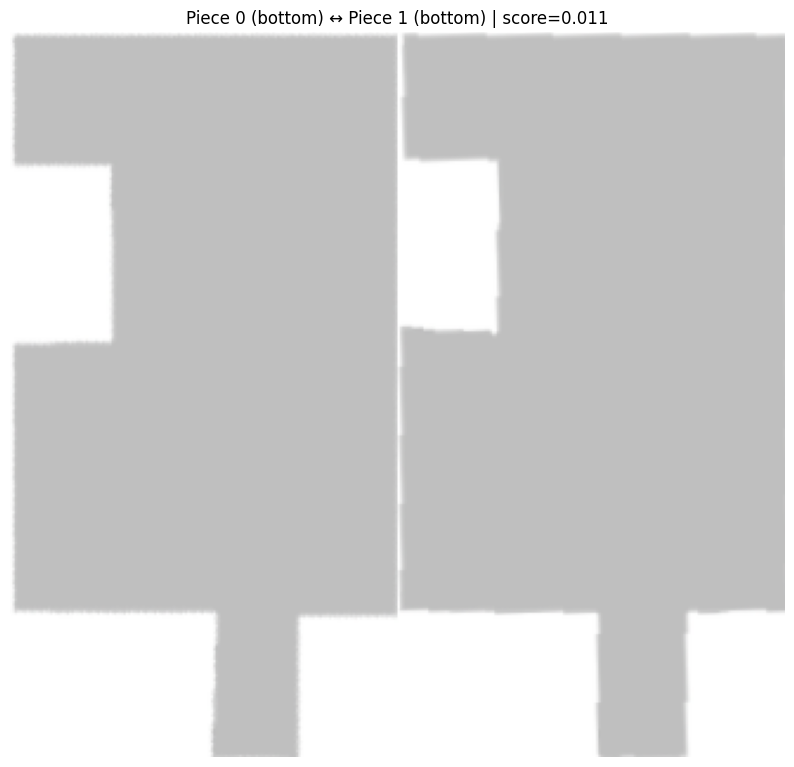

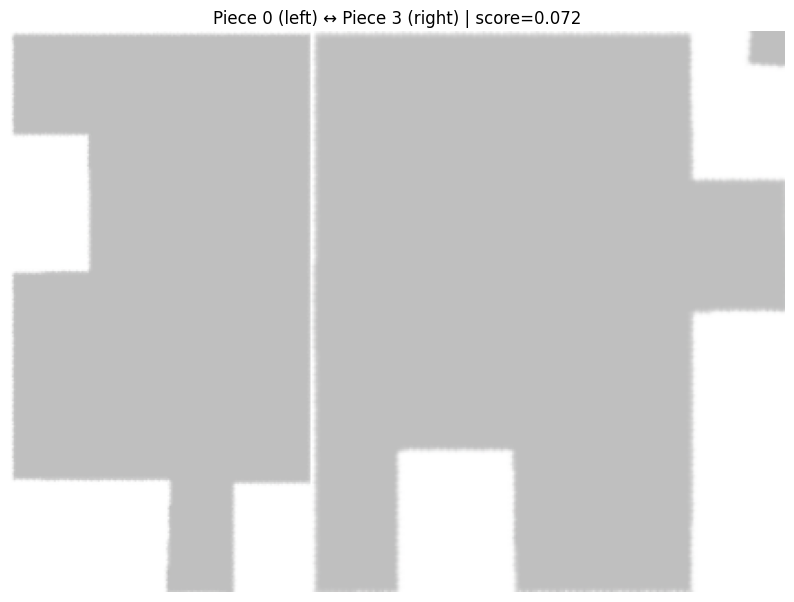

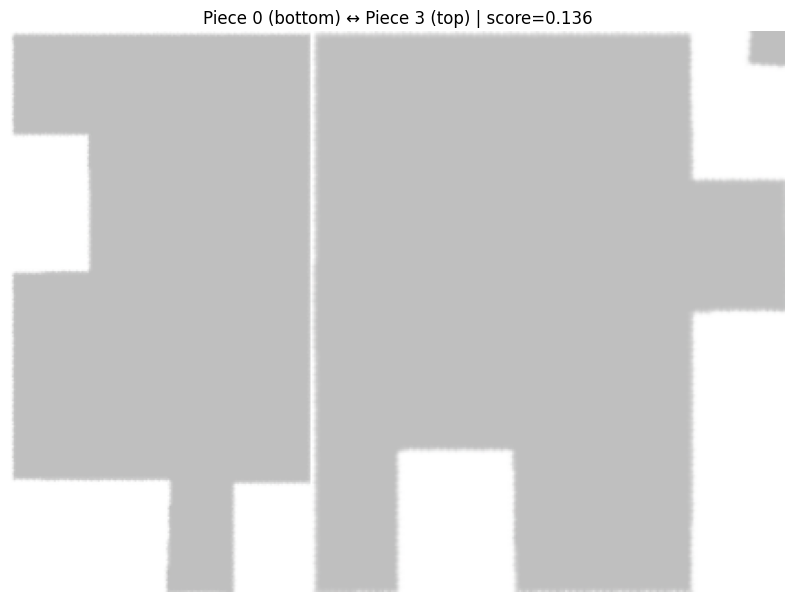

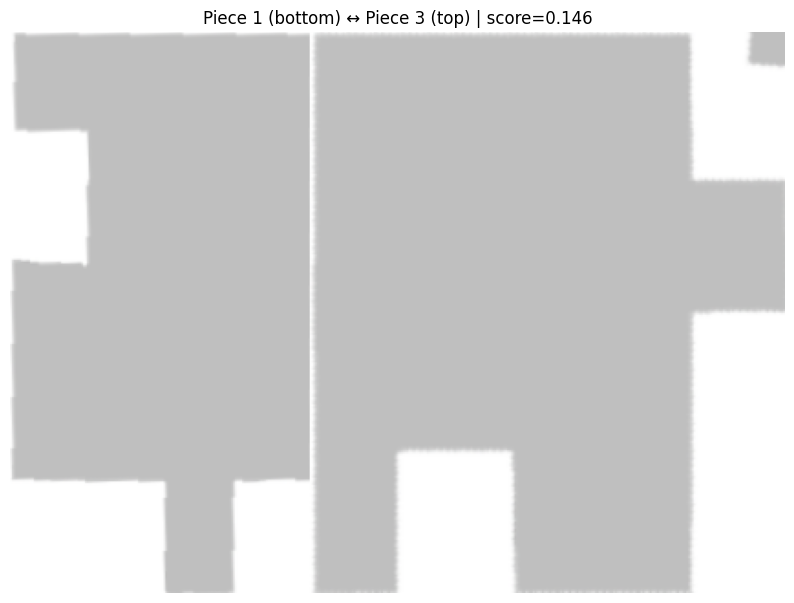

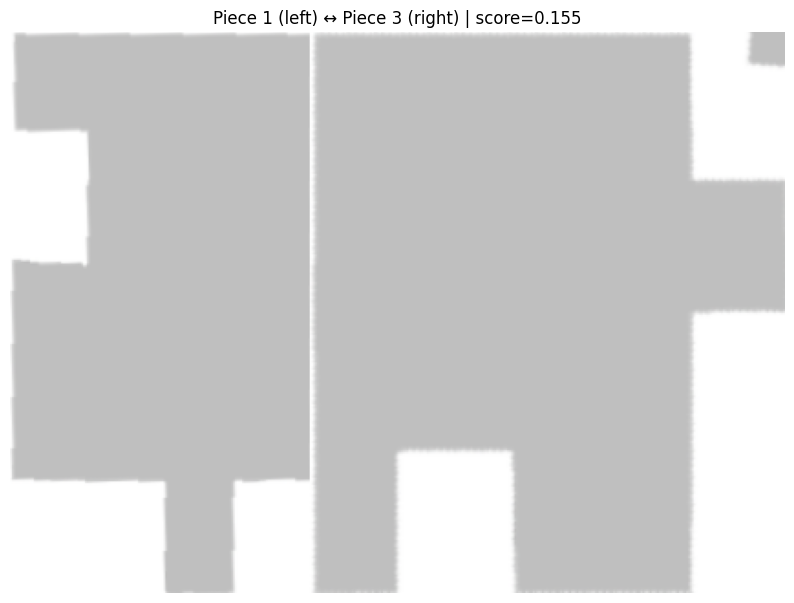

In [13]:
def visualize_match(id_a, side_a, id_b, side_b, score):
    piece_a = extracted_pieces[id_a][0]
    piece_b = extracted_pieces[id_b][0]

    # Match heights before horizontal stacking
    h1, w1 = piece_a.shape[:2]
    h2, w2 = piece_b.shape[:2]
    h = max(h1, h2)

    # Resize both to same height for visualization only
    piece_a_resized = cv2.resize(piece_a, (int(w1 * h / h1), h))
    piece_b_resized = cv2.resize(piece_b, (int(w2 * h / h2), h))

    combined = np.hstack((piece_a_resized, piece_b_resized))
    show(combined, f"Piece {id_a} ({side_a}) ↔ Piece {id_b} ({side_b}) | score={score:.3f}", size=10)


# Show top 5 matches
for m in matches[:5]:
    visualize_match(*m)
